# Credit Risk Threshold Optimizer: Where Should a Lender Draw the Approval Line?

A default-risk model only outputs a probability. Someone still has to pick the
cutoff that turns "9% chance of default" into "approve" or "decline" -- and
almost every intro credit-risk project defaults that cutoff to 0.5 without ever
asking whether 0.5 is the right number in dollar terms.

This notebook walks through: **load -> clean -> baseline model -> cost curve ->
SHAP explanations -> conclusions**, treating the threshold itself, not the
model, as the thing worth optimizing.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
SRC = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)


## 1. Load

Loading prefers the real Kaggle `application_train.csv` if it's present under
`data/raw/`; otherwise it falls back to the bundled synthetic sample so this
notebook runs with zero setup. The synthetic data is built to mimic the real
dataset's known quirks (see below) rather than being pure noise.


In [2]:
from data_prep import load_raw_data, clean_and_engineer, DAYS_EMPLOYED_SENTINEL

raw_df = load_raw_data()
print(f"Rows: {len(raw_df):,}  |  Columns: {raw_df.shape[1]}")
print(f"Default rate (TARGET=1): {raw_df['TARGET'].mean():.2%}")
raw_df.head()


[data_prep] Real data not found at /Users/davidfrancisco/Documents/2026-projs/credit-risk-threshold-optimizer/data/raw/application_train.csv; using synthetic sample at /Users/davidfrancisco/Documents/2026-projs/credit-risk-threshold-optimizer/data/sample.csv
Rows: 5,500  |  Columns: 18
Default rate (TARGET=1): 9.22%


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_INCOME_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OWN_CAR_AGE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,100001,0,M,Y,N,1,198900.0,1195300.0,80396.7,Secondary / secondary special,Married,Working,-19840,-817,14.1,0.874081,0.893707,0.521980
1,100002,1,F,N,Y,0,145900.0,883700.0,87083.1,Higher education,Civil marriage,Commercial associate,-8747,-1658,NaN,NaN,0.542643,0.591099
2,100003,0,M,Y,N,1,244500.0,1149900.0,47650.0,Secondary / secondary special,Married,Commercial associate,-23900,-705,18.5,0.612493,0.857643,0.770925
3,100004,0,M,N,N,1,116800.0,265400.0,10242.0,Secondary / secondary special,Single / not married,Working,-15188,-2474,NaN,0.685291,0.784301,0.677781
4,100005,0,F,N,N,0,155400.0,363100.0,26567.1,Secondary / secondary special,Civil marriage,Working,-15619,-574,NaN,NaN,0.498797,0.364791


## 2. Clean: the `DAYS_EMPLOYED` anomaly

The real Home Credit dataset encodes "not currently employed" (mainly
pensioners and the unemployed) as the literal sentinel value **365,243** in
`DAYS_EMPLOYED` -- roughly 1,000 years of tenure -- instead of a proper missing
value. Treat that as a real day-count and every derived "years employed"
feature for those rows becomes nonsense. This is a well-documented trap in
this specific dataset, and it's reproduced deliberately in the synthetic
fallback so the cleaning step has something real to catch.

The fix: flag it first (the flag itself turns out to be predictive -- it
correlates with being retired/unemployed), then null it out before any
numeric use.


In [3]:
sentinel_count = (raw_df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_SENTINEL).sum()
print(f"Rows with the DAYS_EMPLOYED sentinel (365243): {sentinel_count:,} "
      f"({sentinel_count / len(raw_df):.1%} of all rows)")

df = clean_and_engineer(raw_df)
df[["FLAG_EMPLOYED_ANOMALY", "DAYS_EMPLOYED", "YEARS_EMPLOYED"]].describe()


Rows with the DAYS_EMPLOYED sentinel (365243): 1,072 (19.5% of all rows)


,FLAG_EMPLOYED_ANOMALY,DAYS_EMPLOYED,YEARS_EMPLOYED
count,5500.000000,4428.000000,4428.000000
mean,0.194909,-1385.758582,3.794000
std,0.396167,1320.484966,3.615291
min,0.000000,-10347.000000,-0.000000
25%,0.000000,-1923.250000,1.141684
50%,0.000000,-986.000000,2.699521
75%,0.000000,-417.000000,5.265572
max,1.000000,0.000000,28.328542


In [4]:
print("Missingness in key columns after cleaning:")
df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "OWN_CAR_AGE", "YEARS_EMPLOYED"]].isna().mean().round(3)


Missingness in key columns after cleaning:


EXT_SOURCE_1      0.549
EXT_SOURCE_2      0.020
EXT_SOURCE_3      0.199
OWN_CAR_AGE       0.668
YEARS_EMPLOYED    0.195
dtype: float64

Engineered features added on top of the raw columns: `AGE_YEARS` (from
`DAYS_BIRTH`), `YEARS_EMPLOYED` (from the cleaned `DAYS_EMPLOYED`), and
`DEBT_TO_INCOME` (`AMT_CREDIT / AMT_INCOME_TOTAL`) -- all things a
non-technical stakeholder can reason about directly, which matters later when
we explain individual decisions.

**Note on imputation:** missing values in `EXT_SOURCE_1` etc. are *not*
filled in here. Imputation is fit on the training split only, inside
`model.py`, so no information about the test set's distribution leaks into
training.


## 3. Baseline model: why 0.5 is an arbitrary starting point

A `RandomForestClassifier` with `class_weight="balanced"` (defaults are a
small minority of applicants -- around 9% here -- so an unweighted model would
just learn to predict "no default" for everyone and look falsely accurate).
Train/test split is stratified with a fixed seed so this is exactly
reproducible.

0.5 is the default decision boundary scikit-learn's `.predict()` uses, but
it has no relationship to the actual dollar cost of the two ways this model
can be wrong. The classification report below is the baseline the cost
analysis needs to visibly beat -- not because 0.5 is a bad threshold on its
face, but because nobody chose it for a reason.


In [5]:
from model import train_baseline_model, evaluate_baseline

trained = train_baseline_model()
results = evaluate_baseline(trained)

print(f"Test set size: {len(trained.y_test):,}  |  test default rate: {trained.y_test.mean():.2%}")
print(f"\nBaseline ROC AUC: {results['auc']:.4f}")
print("\nClassification report @ naive 0.5 threshold:")
print(results["report"])


[data_prep] Real data not found at /Users/davidfrancisco/Documents/2026-projs/credit-risk-threshold-optimizer/data/raw/application_train.csv; using synthetic sample at /Users/davidfrancisco/Documents/2026-projs/credit-risk-threshold-optimizer/data/sample.csv


Test set size: 1,375  |  test default rate: 9.24%

Baseline ROC AUC: 0.7428

Classification report @ naive 0.5 threshold:
              precision    recall  f1-score   support

           0      0.950     0.781     0.858      1248
           1      0.218     0.598     0.319       127

    accuracy                          0.764      1375
   macro avg      0.584     0.690     0.588      1375
weighted avg      0.883     0.764     0.808      1375



## 4. Cost curve: the payoff

Two dollar costs, swept across every threshold from 0.01 to 0.99:

- **Approved defaults**: applicants below the threshold (approved) who
  actually default. Cost = loan amount x `LOSS_GIVEN_DEFAULT` (60%, illustrative).
- **Wrongly rejected good applicants**: applicants above the threshold
  (declined) who would *not* have defaulted. Cost = loan amount x
  `EXPECTED_MARGIN` (12%, illustrative -- forgone profit on a loan that would
  have performed fine).

Both constants are clearly-labeled assumptions, not real underwriting
economics -- see the README for the reasoning behind these specific numbers.


Loss given default assumption: 60% of loan amount
Expected margin assumption: 12% of loan amount

Optimal threshold: 0.52  ->  total cost $42,157,848
Naive 0.5 threshold: total cost $44,582,772
Approve-everyone (threshold=1.0): total cost $56,520,780

$ saved vs. naive 0.5 threshold: $2,424,924
$ saved vs. approving everyone: $14,362,932


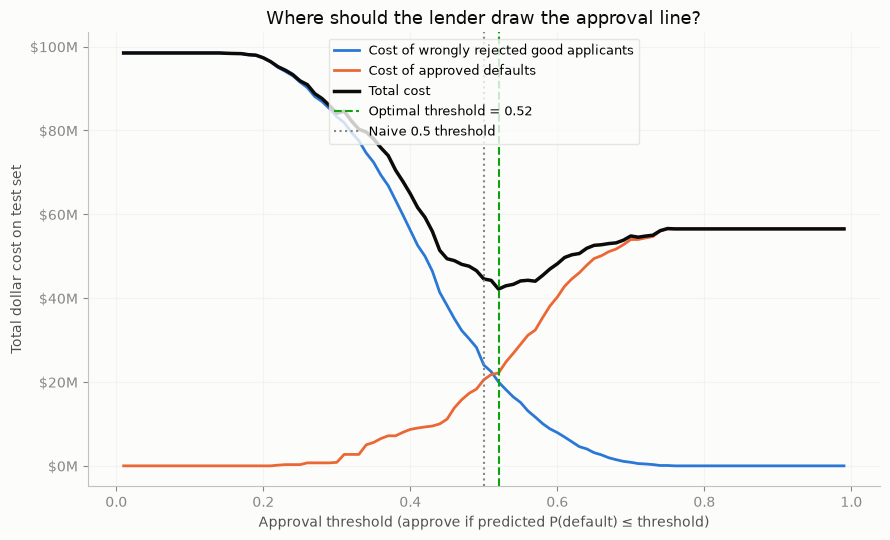

In [6]:
from cost_analysis import (
    sweep_thresholds, cost_at_threshold, approve_everyone_cost,
    plot_cost_curves, LOSS_GIVEN_DEFAULT, EXPECTED_MARGIN,
)

proba = results["proba"]
y_true = trained.y_test.to_numpy()
loan_amount = trained.test_raw["AMT_CREDIT"].to_numpy()

sweep_df = sweep_thresholds(proba, y_true, loan_amount)
best_row = sweep_df.loc[sweep_df["total_cost"].idxmin()]
optimal_threshold = float(best_row["threshold"])
optimal_cost = float(best_row["total_cost"])

cost_at_naive = cost_at_threshold(proba, y_true, loan_amount, 0.5)
cost_approve_all = approve_everyone_cost(y_true, loan_amount)

print(f"Loss given default assumption: {LOSS_GIVEN_DEFAULT:.0%} of loan amount")
print(f"Expected margin assumption: {EXPECTED_MARGIN:.0%} of loan amount")
print()
print(f"Optimal threshold: {optimal_threshold:.2f}  ->  total cost ${optimal_cost:,.0f}")
print(f"Naive 0.5 threshold: total cost ${cost_at_naive:,.0f}")
print(f"Approve-everyone (threshold=1.0): total cost ${cost_approve_all:,.0f}")
print()
print(f"$ saved vs. naive 0.5 threshold: ${cost_at_naive - optimal_cost:,.0f}")
print(f"$ saved vs. approving everyone: ${cost_approve_all - optimal_cost:,.0f}")

fig = plot_cost_curves(sweep_df, optimal_threshold)
plt.show()


**Reading this curve:** the optimal threshold (0.52) lands close to the
naive 0.5 cutoff here -- not because 0.5 was secretly the right answer, but
because `class_weight="balanced"` already pushed the model's probabilities
into a reasonably well-calibrated range. The point isn't that 0.5 is
*wildly* wrong in this particular run; it's that there was no way to know it
was close to right without actually doing the cost analysis. On a
differently-calibrated model, or with different cost assumptions, this gap
could easily be much larger -- and the only way to find out is to sweep it,
not assume it.


## 5. SHAP: explaining individual decisions

Global feature ranking (mean absolute SHAP value, sampled from the test set)
and one local, plain-English explanation for a specific declined applicant --
written so a non-technical manager could read it without a legend.

SHAP's output shape for classifiers is inconsistent across versions (a list
of per-class arrays, a 3D array, or already 2D for the positive class);
`explain.py` normalizes this explicitly rather than assuming one shape.


Top 10 features by mean |SHAP| on a 300-row test sample:


,feature,mean_abs_shap
0,EXT_SOURCE_2,0.061053
1,EXT_SOURCE_3,0.049534
2,EXT_SOURCE_1,0.035555
3,DEBT_TO_INCOME,0.025094
4,AMT_INCOME_TOTAL,0.009990
5,AMT_ANNUITY,0.008363
6,AMT_CREDIT,0.007816
7,AGE_YEARS,0.007068
8,YEARS_EMPLOYED,0.004143
9,OWN_CAR_AGE,0.003755


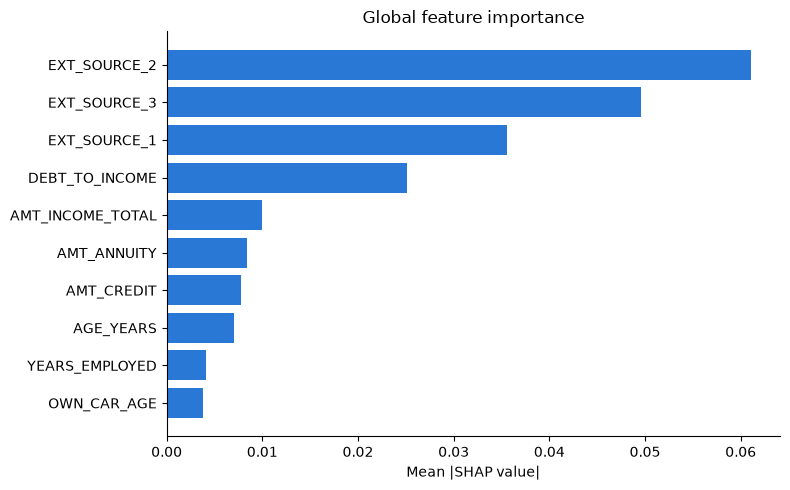


Top 3 drivers overall:
  - EXT_SOURCE_2: mean |SHAP| = 0.0611
  - EXT_SOURCE_3: mean |SHAP| = 0.0495
  - EXT_SOURCE_1: mean |SHAP| = 0.0356


In [7]:
from explain import global_feature_ranking, explain_applicant, pick_declined_applicant

ranking = global_feature_ranking(trained)
print("Top 10 features by mean |SHAP| on a 300-row test sample:")
display(ranking.head(10))

fig, ax = plt.subplots(figsize=(8, 5))
top10 = ranking.head(10).iloc[::-1]
ax.barh(top10["feature"], top10["mean_abs_shap"], color="#2a78d6")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Global feature importance")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print("\nTop 3 drivers overall:")
for _, row in ranking.head(3).iterrows():
    print(f"  - {row['feature']}: mean |SHAP| = {row['mean_abs_shap']:.4f}")


In [8]:
idx = pick_declined_applicant(trained, proba)
result = explain_applicant(trained, idx)
print(result["narrative"])


Applicant 103791 was predicted to have a 75% chance of default and would be declined under this model. Factors that pushed their risk score up: a second external credit bureau score that is low for this applicant pool (0.37 vs. a typical 0.63), an external credit bureau score that is low for this applicant pool (0.47 vs. a typical 0.63), a third external credit bureau score that is low for this applicant pool (0.36 vs. a typical 0.63), the loan annuity payment that is high for this applicant pool (46647.00 vs. a typical 29654.20). Factors that pushed their risk score down (worked in their favor): applicant age that is high for this applicant pool (53.74 vs. a typical 45.48), years at current employment that is low for this applicant pool (2.53 vs. a typical 2.72), a family status of "Single / not married", a gender of "M".


## 6. Conclusions and limitations

**What this shows:**
- A baseline model with real (if modest) signal -- ROC AUC well above a
  random baseline -- is enough to make the *threshold* decision meaningful.
- Sweeping the threshold against two named dollar costs turns "pick a
  cutoff" from a default into a defensible, visualized decision, with a
  measurable dollar improvement over both the naive 0.5 cutoff and the
  approve-everyone baseline.
- SHAP turns "the model said no" into a specific, checkable reason a
  non-technical stakeholder (or the declined applicant) could actually read.

**Limitations, stated plainly:**
- The primary run above uses the **bundled synthetic sample**, not the real
  Kaggle data (see the README for how to switch to the real
  `application_train.csv`). The synthetic data is built to mimic the real
  dataset's known quirks and signal structure, but real applicant behavior is
  messier than any generator captures.
- `LOSS_GIVEN_DEFAULT` (60%) and `EXPECTED_MARGIN` (12%) are illustrative
  assumptions, not a real lender's actual unit economics. The *shape* of the
  cost curve and the *method* generalize; the specific optimal threshold does
  not, if those constants change.
- The model only uses the single `application` table. The out-of-scope list
  in the PRD notes that joining `bureau.csv` / `previous_application.csv`, or
  comparing against a gradient-boosted model, would likely improve AUC
  further -- neither was the point of this project.
- This is not a production scoring system: no monitoring, no drift
  detection, no calibration recheck over time.
